In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (r2_score, mean_squared_error, 
                             mean_absolute_error)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Setup plot ───────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# ── Load data ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = joblib.load('models/data_split_regression.pkl')
feature_cols = joblib.load('models/feature_cols.pkl')

# ── Load semua model baseline ────────────────────────────────
rf_base    = joblib.load('models/rf_model.pkl')
xgb_base   = joblib.load('models/xgb_model.pkl')
lgbm_base  = joblib.load('models/lgbm_model.pkl')
ridge_base = joblib.load('models/ridge_model.pkl')
svr_base   = joblib.load('models/svr_model.pkl')

# ── Load semua model weighted ────────────────────────────────
rf_w    = joblib.load('models/rf_weighted_model.pkl')
xgb_w   = joblib.load('models/xgb_weighted_model.pkl')
lgbm_w  = joblib.load('models/lgbm_weighted_model.pkl')
ridge_w = joblib.load('models/ridge_weighted_model.pkl')
svr_w   = joblib.load('models/svr_weighted_model.pkl')

# ── Load hasil CSV ───────────────────────────────────────────
baseline_results = pd.read_csv('data/regression_results.csv')
weighted_results = pd.read_csv('data/weighted_results.csv')

# ── Dict model untuk iterasi ─────────────────────────────────
baseline_models = {
    'Random Forest' : rf_base,
    'XGBoost'       : xgb_base,
    'LightGBM'      : lgbm_base,
    'Ridge'         : ridge_base,
    'SVR'           : svr_base
}

weighted_models = {
    'Random Forest' : rf_w,
    'XGBoost'       : xgb_w,
    'LightGBM'      : lgbm_w,
    'Ridge'         : ridge_w,
    'SVR'           : svr_w
}

# ── Setup platform untuk analisis per platform ───────────────
platform_cols = [col for col in feature_cols if col.startswith('platform_')]

def get_platform(row):
    for col in platform_cols:
        if row[col] == 1:
            return col.replace('platform_', '')
    return 'Unknown'

X_test_df = pd.DataFrame(X_test, columns=feature_cols)
test_platforms = X_test_df.apply(get_platform, axis=1)

print("✅ Semua data & model berhasil dimuat!")
print(f"\n📊 Dataset:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test : {X_test.shape}")
print(f"\n🤖 Models loaded:")
print(f"   Baseline: {list(baseline_models.keys())}")
print(f"   Weighted: {list(weighted_models.keys())}")
print(f"\n🏨 Platforms di test set: {sorted(test_platforms.unique())}")


✅ Semua data & model berhasil dimuat!

📊 Dataset:
   X_train: (3946, 12)
   X_test : (987, 12)

🤖 Models loaded:
   Baseline: ['Random Forest', 'XGBoost', 'LightGBM', 'Ridge', 'SVR']
   Weighted: ['Random Forest', 'XGBoost', 'LightGBM', 'Ridge', 'SVR']

🏨 Platforms di test set: ['Agoda', 'Booking.com', 'Tiket.com', 'Traveloka', 'Trip.com']


HASIL PERBANDINGAN LIMA MODEL BASELINE


,Model,RMSE Train,RMSE Test,MAE Test,R2 Train,R2 Test,Gap,Status
0,SVR (Tuned),0.1476,0.1527,0.1229,0.6229,0.6277,-0.0048,Normal
1,Ridge (Tuned),0.1495,0.1531,0.1229,0.6129,0.6258,-0.0129,Normal
2,XGBoost (Tuned),0.1408,0.1556,0.1248,0.6569,0.6135,0.0434,Normal
3,LightGBM (Tuned),0.1372,0.1560,0.1257,0.6738,0.6114,0.0624,Normal
4,Random Forest,0.0626,0.1613,0.1290,0.9321,0.5849,0.3472,Overfit


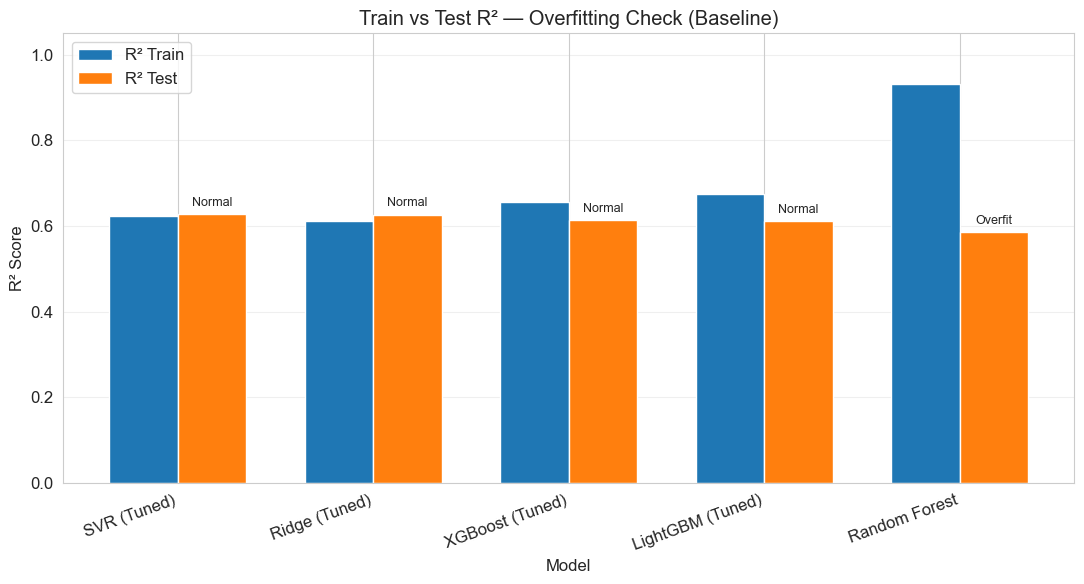

File berhasil disimpan:
- data/bab4_baseline_model_results.csv
- plots/reg_overfitting_check.png


In [2]:
# Hasil Perbandingan Lima Model Baseline

def calculate_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

baseline_rows = []

for model_name, model in baseline_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train = calculate_rmse(y_train, y_train_pred)
    rmse_test = calculate_rmse(y_test, y_test_pred)
    mae_test = np.mean(np.abs(y_test - y_test_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    gap = r2_train - r2_test

    display_name = 'Random Forest' if model_name == 'Random Forest' else f'{model_name} (Tuned)'

    baseline_rows.append({
        'Model': display_name,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'MAE Test': mae_test,
        'R2 Train': r2_train,
        'R2 Test': r2_test,
        'Gap': gap,
        'Status': 'Overfit' if gap > 0.1 else 'Normal'
    })

baseline_summary = pd.DataFrame(baseline_rows)

baseline_summary = baseline_summary.sort_values(
    'R2 Test',
    ascending=False
).reset_index(drop=True)


baseline_report = baseline_summary.copy()

baseline_report[
    ['RMSE Train', 'RMSE Test', 'MAE Test', 'R2 Train', 'R2 Test', 'Gap']
] = baseline_report[
    ['RMSE Train', 'RMSE Test', 'MAE Test', 'R2 Train', 'R2 Test', 'Gap']
].round(4)

print("=" * 80)
print("HASIL PERBANDINGAN LIMA MODEL BASELINE")
print("=" * 80)

display(baseline_report)

baseline_report.to_csv(
    'data/bab4_baseline_model_results.csv',
    index=False
)

# Plot Train vs Test R2 untuk Overfitting Check

plot_df = baseline_summary.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    plot_df['R2 Train'],
    width,
    label='R² Train'
)

plt.bar(
    x + width / 2,
    plot_df['R2 Test'],
    width,
    label='R² Test'
)

plt.xticks(
    x,
    plot_df['Model'],
    rotation=20,
    ha='right'
)

plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('Train vs Test R² — Overfitting Check (Baseline)')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, row in plot_df.iterrows():
    plt.text(
        i + width / 2,
        row['R2 Test'] + 0.02,
        row['Status'],
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    'plots/reg_overfitting_check.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("File berhasil disimpan:")
print("- data/bab4_baseline_model_results.csv")
print("- plots/reg_overfitting_check.png")

In [3]:
comparison_rows = []

for model_name in baseline_models.keys():
    base_row = baseline_results[
        baseline_results['Model'].str.contains(model_name, case=False)
    ].iloc[0]
    w_row = weighted_results[
        weighted_results['Model'].str.contains(model_name, case=False)
    ].iloc[0]
    
    comparison_rows.append({
        'Model'         : model_name,
        'RMSE_Base'     : float(base_row['RMSE_Test']),
        'RMSE_W'        : float(w_row['RMSE_Test']),
        'MAE_Base'      : float(base_row['MAE_Test']),
        'MAE_W'         : float(w_row['MAE_Test']),
        'R2_Base'       : float(base_row['R2_Test']),
        'R2_W'          : float(w_row['R2_Test']),
        'R2_Improvement': float(w_row['R2_Test']) - float(base_row['R2_Test'])
    })

comp_df = pd.DataFrame(comparison_rows).round(4)
comp_df = comp_df.sort_values('R2_W', ascending=False).reset_index(drop=True)
comp_df.index += 1

print("="*80)
print("🏆 PERBANDINGAN 5 MODEL: BASELINE vs WEIGHTED")
print("="*80)
print(comp_df.to_string())

print("\n📌 Keterangan:")
print("   RMSE_Base, MAE_Base, R2_Base → hasil training tanpa weighted")
print("   RMSE_W, MAE_W, R2_W         → hasil training dengan weighted")
print("   R2_Improvement              → selisih R² (weighted - baseline)")

# Simpan ke CSV
comp_df.to_csv('data/model_comparison_05b.csv', index=False)
print("\n✅ Tabel tersimpan: data/model_comparison_05b.csv")

🏆 PERBANDINGAN 5 MODEL: BASELINE vs WEIGHTED
           Model  RMSE_Base  RMSE_W  MAE_Base   MAE_W  R2_Base    R2_W  R2_Improvement
1            SVR     0.1400  0.1528    0.1102  0.1228   0.6564  0.6275         -0.0289
2          Ridge     0.1407  0.1531    0.1106  0.1230   0.6528  0.6260         -0.0268
3        XGBoost     0.1437  0.1561    0.1133  0.1256   0.6375  0.6109         -0.0266
4       LightGBM     0.1442  0.1563    0.1135  0.1261   0.6351  0.6102         -0.0249
5  Random Forest     0.1472  0.1606    0.1153  0.1284   0.6198  0.5882         -0.0316

📌 Keterangan:
   RMSE_Base, MAE_Base, R2_Base → hasil training tanpa weighted
   RMSE_W, MAE_W, R2_W         → hasil training dengan weighted
   R2_Improvement              → selisih R² (weighted - baseline)

✅ Tabel tersimpan: data/model_comparison_05b.csv


PERBANDINGAN PERFORMA MODEL BASELINE VS WEIGHTED TRAINING


,Model,RMSE Baseline,RMSE Weighted,MAE Baseline,MAE Weighted,R² Baseline,R² Weighted,Perubahan R²
0,SVR,0.1527,0.1528,0.1229,0.1228,0.6277,0.6275,-0.0003
1,Ridge,0.1531,0.1531,0.1229,0.1230,0.6258,0.6260,0.0002
2,XGBoost,0.1556,0.1561,0.1248,0.1256,0.6135,0.6109,-0.0026
3,LightGBM,0.1560,0.1563,0.1257,0.1261,0.6114,0.6102,-0.0012
4,Random Forest,0.1613,0.1606,0.1290,0.1284,0.5849,0.5882,0.0032


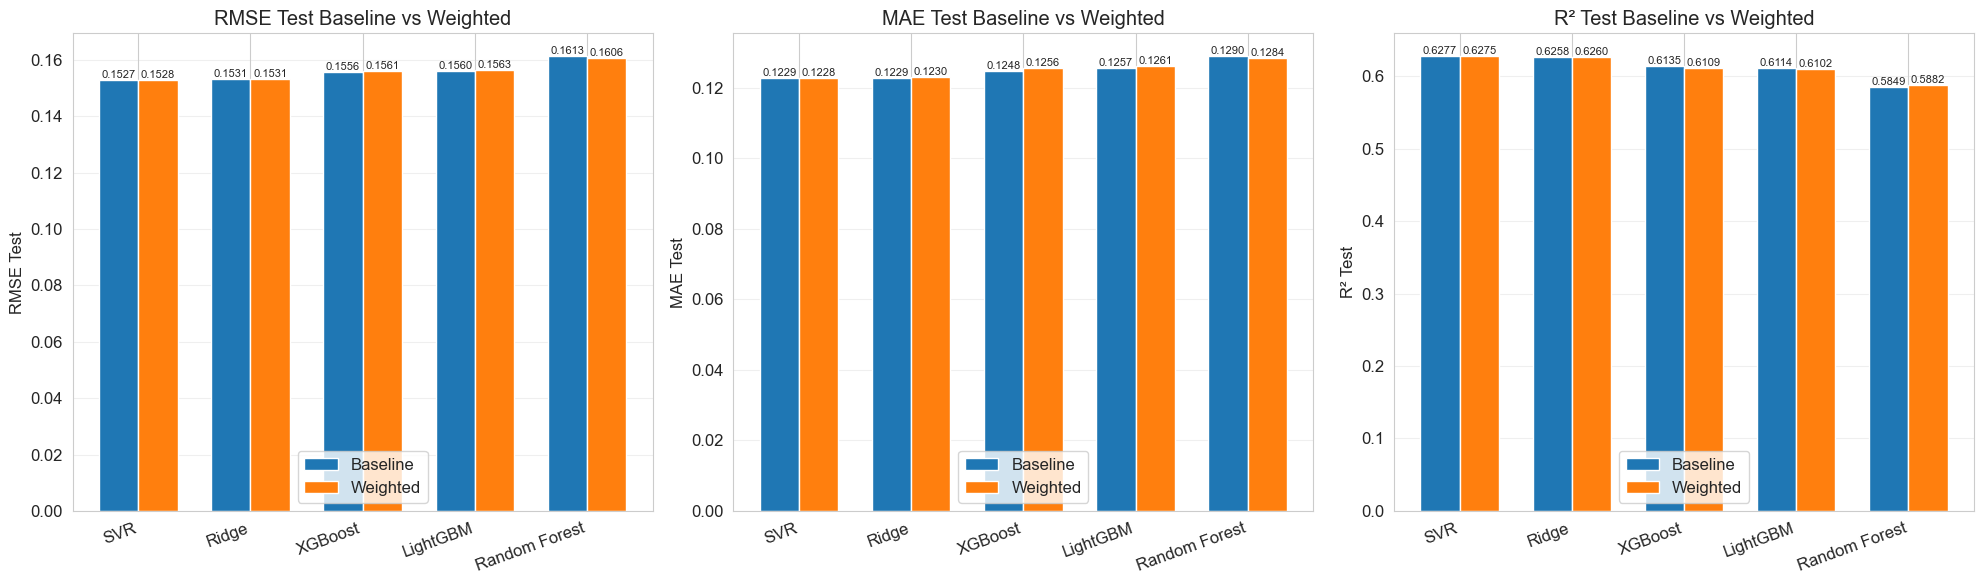

File berhasil disimpan:
- data/bab4_baseline_vs_weighted_results.csv
- plots/05b_model_comparison_metrics.png


In [4]:
#  Perbandingan Baseline vs Weighted Training

pd.io.common.os.makedirs('data', exist_ok=True)
pd.io.common.os.makedirs('plots', exist_ok=True)

def calculate_regression_metrics(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE Test': mean_absolute_error(y_test, y_test_pred),
        'R² Train': r2_score(y_train, y_train_pred),
        'R² Test': r2_score(y_test, y_test_pred)
    }

comparison_rows = []

for model_name in baseline_models.keys():
    base_metrics = calculate_regression_metrics(
        baseline_models[model_name],
        X_train,
        X_test,
        y_train,
        y_test
    )

    weighted_metrics = calculate_regression_metrics(
        weighted_models[model_name],
        X_train,
        X_test,
        y_train,
        y_test
    )

    comparison_rows.append({
        'Model': model_name,
        'RMSE Baseline': base_metrics['RMSE Test'],
        'RMSE Weighted': weighted_metrics['RMSE Test'],
        'MAE Baseline': base_metrics['MAE Test'],
        'MAE Weighted': weighted_metrics['MAE Test'],
        'R² Baseline': base_metrics['R² Test'],
        'R² Weighted': weighted_metrics['R² Test'],
        'Perubahan R²': weighted_metrics['R² Test'] - base_metrics['R² Test']
    })

weighted_comparison_df = pd.DataFrame(comparison_rows)

weighted_comparison_df = weighted_comparison_df.sort_values(
    'R² Weighted',
    ascending=False
).reset_index(drop=True)

weighted_comparison_report = weighted_comparison_df.copy()

weighted_comparison_report[
    ['RMSE Baseline', 'RMSE Weighted', 'MAE Baseline', 'MAE Weighted',
     'R² Baseline', 'R² Weighted', 'Perubahan R²']
] = weighted_comparison_report[
    ['RMSE Baseline', 'RMSE Weighted', 'MAE Baseline', 'MAE Weighted',
     'R² Baseline', 'R² Weighted', 'Perubahan R²']
].round(4)

print("=" * 90)
print("PERBANDINGAN PERFORMA MODEL BASELINE VS WEIGHTED TRAINING")
print("=" * 90)

display(weighted_comparison_report)

weighted_comparison_report.to_csv(
    'data/bab4_baseline_vs_weighted_results.csv',
    index=False
)

# Plot perbandingan metrik baseline vs weighted

models_order = weighted_comparison_report['Model'].tolist()
x = np.arange(len(models_order))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = [
    ('RMSE Baseline', 'RMSE Weighted', 'RMSE Test', 'RMSE Test Baseline vs Weighted'),
    ('MAE Baseline', 'MAE Weighted', 'MAE Test', 'MAE Test Baseline vs Weighted'),
    ('R² Baseline', 'R² Weighted', 'R² Test', 'R² Test Baseline vs Weighted')
]

for ax, (base_col, weighted_col, ylabel, title) in zip(axes, metrics):
    ax.bar(x - width / 2, weighted_comparison_report[base_col], width, label='Baseline')
    ax.bar(x + width / 2, weighted_comparison_report[weighted_col], width, label='Weighted')

    ax.set_xticks(x)
    ax.set_xticklabels(models_order, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, (base_value, weighted_value) in enumerate(
        zip(weighted_comparison_report[base_col], weighted_comparison_report[weighted_col])
    ):
        ax.text(i - width / 2, base_value, f'{base_value:.4f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width / 2, weighted_value, f'{weighted_value:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(
    'plots/05b_model_comparison_metrics.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("File berhasil disimpan:")
print("- data/bab4_baseline_vs_weighted_results.csv")
print("- plots/05b_model_comparison_metrics.png")

EVALUASI XGBoost WEIGHTED PER PLATFORM OTA


,Platform,N Data Test,RMSE,MAE,R²
0,Trip.com,104,0.1672,0.1347,0.5080
1,Agoda,449,0.1443,0.1180,0.5029
2,Booking.com,80,0.1567,0.1339,0.4563
3,Tiket.com,187,0.1668,0.1288,0.4511
4,Traveloka,167,0.1666,0.1328,0.4339


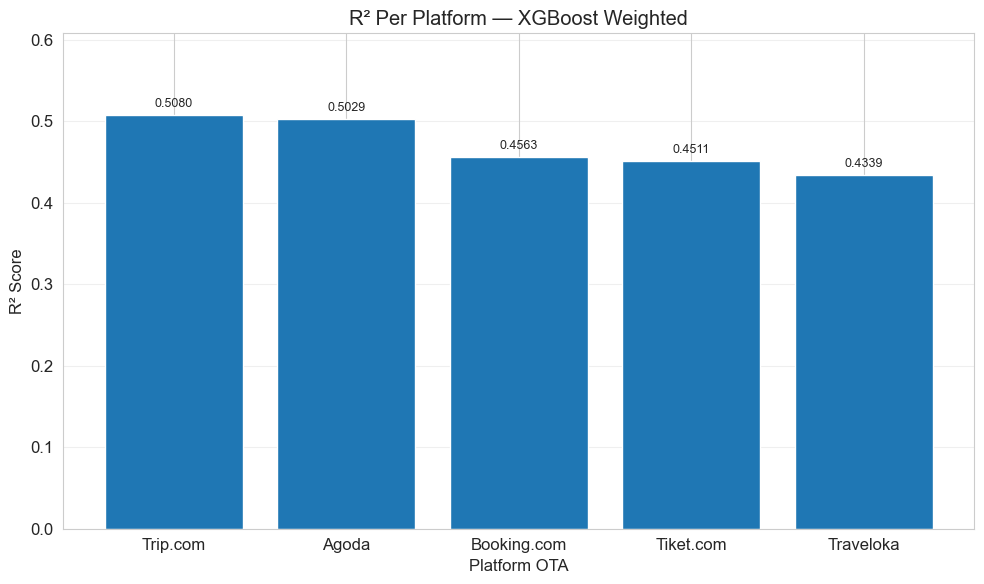

File berhasil disimpan:
- data/bab4_xgboost_weighted_per_platform.csv
- plots/05b_xgboost_weighted_per_platform.png


In [5]:
# Evaluasi Per Platform untuk Model Weighted


selected_model_name = 'XGBoost'
selected_model = weighted_models[selected_model_name]

def select_rows(data, mask_values):
    if hasattr(data, 'iloc'):
        return data.iloc[mask_values]
    return data[mask_values]

per_platform_rows = []

for platform in sorted(test_platforms.unique()):
    mask_values = (test_platforms == platform).values

    if mask_values.sum() < 2:
        continue

    X_platform = select_rows(X_test, mask_values)
    y_platform = np.asarray(y_test)[mask_values]
    y_pred_platform = selected_model.predict(X_platform)

    per_platform_rows.append({
        'Platform': platform,
        'N Data Test': mask_values.sum(),
        'RMSE': np.sqrt(mean_squared_error(y_platform, y_pred_platform)),
        'MAE': mean_absolute_error(y_platform, y_pred_platform),
        'R²': r2_score(y_platform, y_pred_platform)
    })

xgb_platform_df = pd.DataFrame(per_platform_rows)

xgb_platform_df = xgb_platform_df.sort_values(
    'R²',
    ascending=False
).reset_index(drop=True)

xgb_platform_report = xgb_platform_df.copy()

xgb_platform_report[
    ['RMSE', 'MAE', 'R²']
] = xgb_platform_report[
    ['RMSE', 'MAE', 'R²']
].round(4)

print("=" * 80)
print(f"EVALUASI {selected_model_name} WEIGHTED PER PLATFORM OTA")
print("=" * 80)

display(xgb_platform_report)

xgb_platform_report.to_csv(
    'data/bab4_xgboost_weighted_per_platform.csv',
    index=False
)

plt.figure(figsize=(10, 6))
plt.bar(xgb_platform_report['Platform'], xgb_platform_report['R²'])

plt.xlabel('Platform OTA')
plt.ylabel('R² Score')
plt.title(f'R² Per Platform — {selected_model_name} Weighted')
plt.ylim(0, max(xgb_platform_report['R²']) + 0.1)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(xgb_platform_report['R²']):
    plt.text(i, value + 0.01, f'{value:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(
    'plots/05b_xgboost_weighted_per_platform.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("File berhasil disimpan:")
print("- data/bab4_xgboost_weighted_per_platform.csv")
print("- plots/05b_xgboost_weighted_per_platform.png")

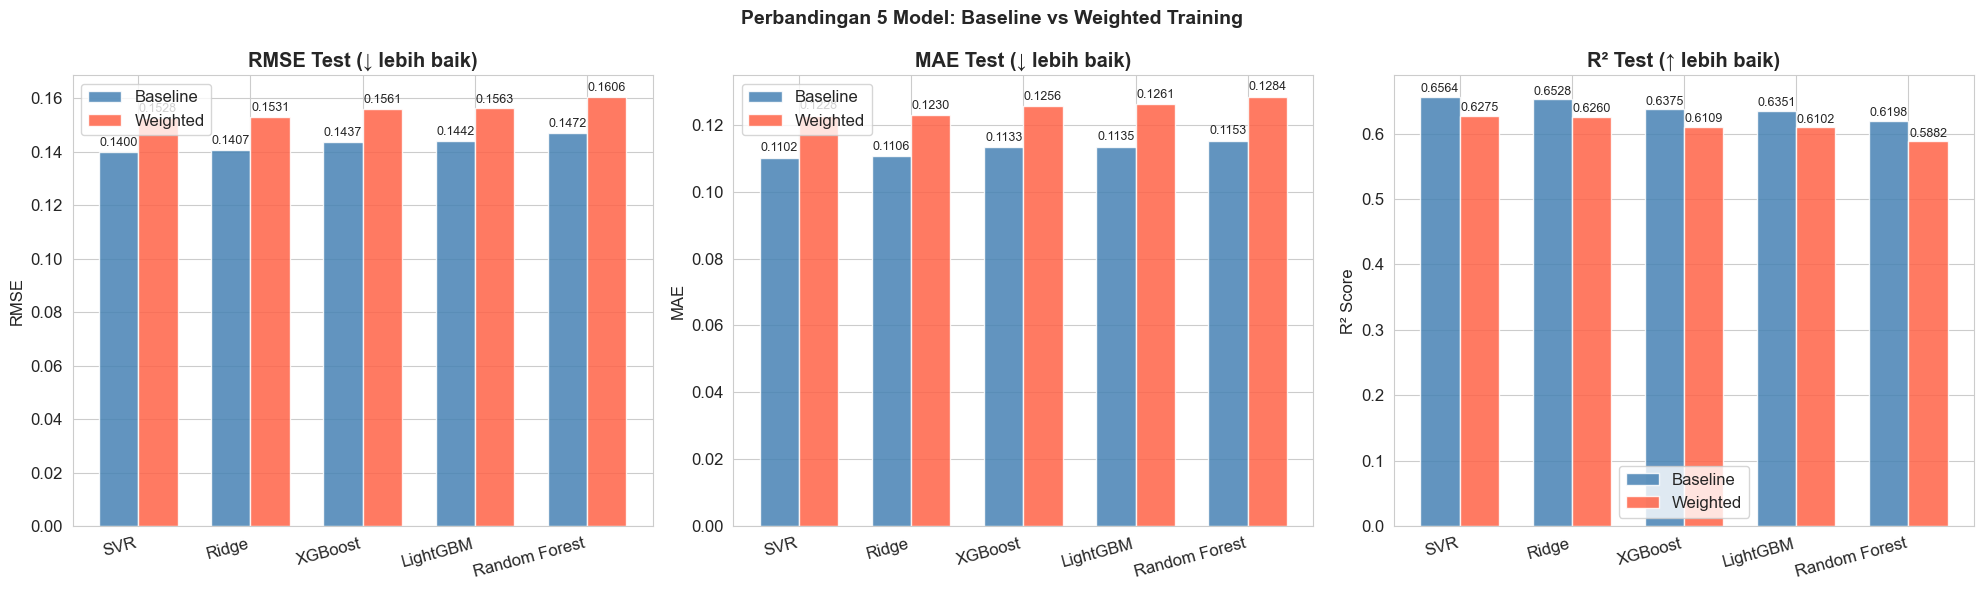


✅ Plot tersimpan: plots/05b_model_comparison_metrics.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_order = comp_df['Model'].tolist()
x = np.arange(len(models_order))
width = 0.35

# ── RMSE ─────────────────────────────────────────────────────
axes[0].bar(x - width/2, comp_df['RMSE_Base'], width,
            label='Baseline', color='steelblue', alpha=0.85,
            edgecolor='white')
axes[0].bar(x + width/2, comp_df['RMSE_W'], width,
            label='Weighted', color='tomato', alpha=0.85,
            edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_order, rotation=15, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Test (↓ lebih baik)', fontweight='bold')
axes[0].legend()

for i, (b, w) in enumerate(zip(comp_df['RMSE_Base'], comp_df['RMSE_W'])):
    axes[0].text(i - width/2, b + 0.001, f'{b:.4f}', 
                 ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, w + 0.001, f'{w:.4f}', 
                 ha='center', va='bottom', fontsize=9)

# ── MAE ──────────────────────────────────────────────────────
axes[1].bar(x - width/2, comp_df['MAE_Base'], width,
            label='Baseline', color='steelblue', alpha=0.85,
            edgecolor='white')
axes[1].bar(x + width/2, comp_df['MAE_W'], width,
            label='Weighted', color='tomato', alpha=0.85,
            edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_order, rotation=15, ha='right')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE Test (↓ lebih baik)', fontweight='bold')
axes[1].legend()

for i, (b, w) in enumerate(zip(comp_df['MAE_Base'], comp_df['MAE_W'])):
    axes[1].text(i - width/2, b + 0.001, f'{b:.4f}', 
                 ha='center', va='bottom', fontsize=9)
    axes[1].text(i + width/2, w + 0.001, f'{w:.4f}', 
                 ha='center', va='bottom', fontsize=9)

# ── R² ───────────────────────────────────────────────────────
axes[2].bar(x - width/2, comp_df['R2_Base'], width,
            label='Baseline', color='steelblue', alpha=0.85,
            edgecolor='white')
axes[2].bar(x + width/2, comp_df['R2_W'], width,
            label='Weighted', color='tomato', alpha=0.85,
            edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_order, rotation=15, ha='right')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Test (↑ lebih baik)', fontweight='bold')
axes[2].legend()

for i, (b, w) in enumerate(zip(comp_df['R2_Base'], comp_df['R2_W'])):
    axes[2].text(i - width/2, b + 0.002, f'{b:.4f}', 
                 ha='center', va='bottom', fontsize=9)
    axes[2].text(i + width/2, w + 0.002, f'{w:.4f}', 
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan 5 Model: Baseline vs Weighted Training',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot tersimpan: plots/05b_model_comparison_metrics.png")

🔍 TRAIN vs TEST GAP (Overfitting Check)
        Model  R2_Train_Base  R2_Test_Base  Gap_Base  R2_Train_W  R2_Test_W   Gap_W
Random Forest         0.9321        0.5849    0.3472      0.9329     0.5882  0.3447
      XGBoost         0.6569        0.6135    0.0434      0.6541     0.6109  0.0432
     LightGBM         0.6738        0.6114    0.0624      0.6708     0.6102  0.0606
        Ridge         0.6129        0.6258   -0.0129      0.6126     0.6260 -0.0134
          SVR         0.6229        0.6277   -0.0048      0.6234     0.6275 -0.0041

📌 Gap > 0.1 → kemungkinan overfit


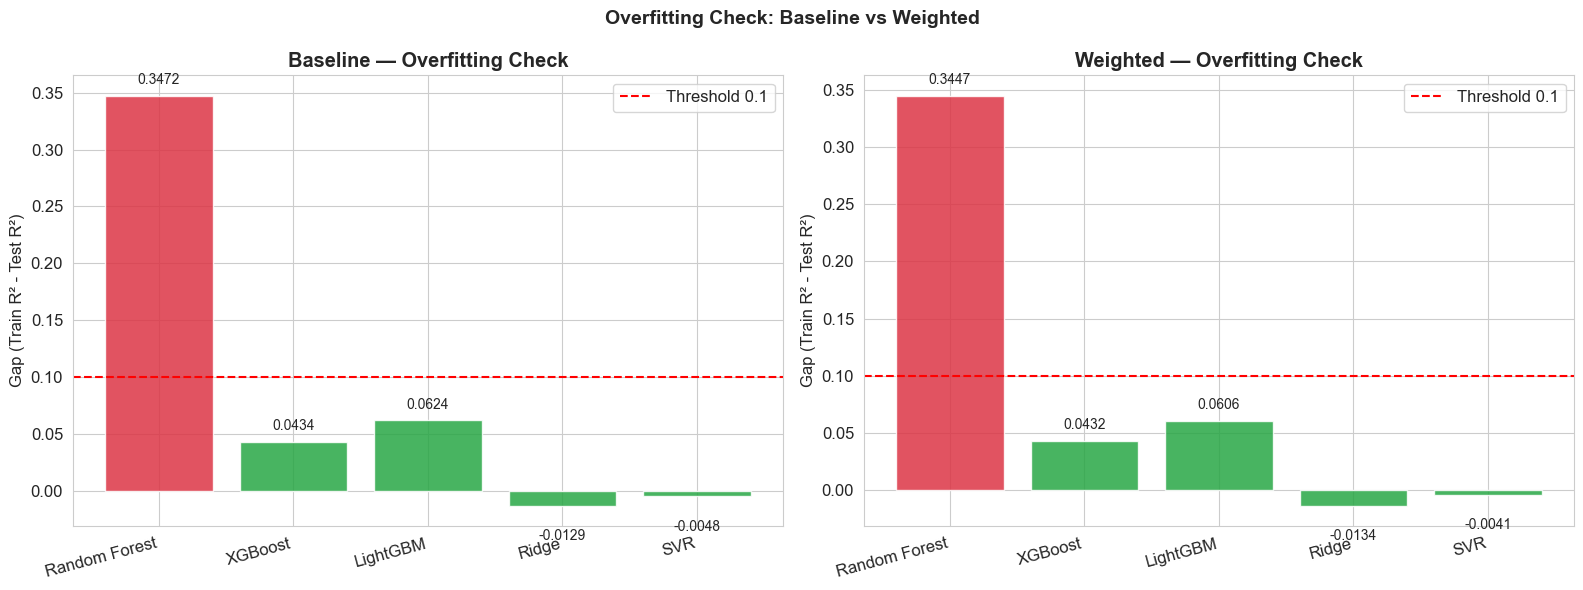


✅ Plot tersimpan: plots/05b_overfitting_check.png


In [7]:
# Hitung R² train untuk semua model
train_test_rows = []

for model_name, model_base in baseline_models.items():
    model_w = weighted_models[model_name]
    
    y_train_pred_base = model_base.predict(X_train)
    y_test_pred_base  = model_base.predict(X_test)
    y_train_pred_w    = model_w.predict(X_train)
    y_test_pred_w     = model_w.predict(X_test)
    
    train_test_rows.append({
        'Model'          : model_name,
        'R2_Train_Base'  : r2_score(y_train, y_train_pred_base),
        'R2_Test_Base'   : r2_score(y_test, y_test_pred_base),
        'Gap_Base'       : r2_score(y_train, y_train_pred_base) - r2_score(y_test, y_test_pred_base),
        'R2_Train_W'     : r2_score(y_train, y_train_pred_w),
        'R2_Test_W'      : r2_score(y_test, y_test_pred_w),
        'Gap_W'          : r2_score(y_train, y_train_pred_w) - r2_score(y_test, y_test_pred_w),
    })

gap_df = pd.DataFrame(train_test_rows).round(4)

print("="*75)
print("🔍 TRAIN vs TEST GAP (Overfitting Check)")
print("="*75)
print(gap_df.to_string(index=False))
print("\n📌 Gap > 0.1 → kemungkinan overfit")

# Visualisasi gap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_order = gap_df['Model'].tolist()
x = np.arange(len(models_order))

# Baseline
axes[0].bar(x, gap_df['Gap_Base'], color=[
    '#dc3545' if g > 0.1 else '#28a745' for g in gap_df['Gap_Base']
], alpha=0.85, edgecolor='white')
axes[0].axhline(0.1, color='red', linestyle='--', linewidth=1.5, 
                label='Threshold 0.1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_order, rotation=15, ha='right')
axes[0].set_ylabel('Gap (Train R² - Test R²)')
axes[0].set_title('Baseline — Overfitting Check', fontweight='bold')
axes[0].legend()

for i, v in enumerate(gap_df['Gap_Base']):
    axes[0].text(i, v + 0.01 if v > 0 else v - 0.03, f'{v:.4f}',
                 ha='center', fontsize=10)

# Weighted
axes[1].bar(x, gap_df['Gap_W'], color=[
    '#dc3545' if g > 0.1 else '#28a745' for g in gap_df['Gap_W']
], alpha=0.85, edgecolor='white')
axes[1].axhline(0.1, color='red', linestyle='--', linewidth=1.5,
                label='Threshold 0.1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_order, rotation=15, ha='right')
axes[1].set_ylabel('Gap (Train R² - Test R²)')
axes[1].set_title('Weighted — Overfitting Check', fontweight='bold')
axes[1].legend()

for i, v in enumerate(gap_df['Gap_W']):
    axes[1].text(i, v + 0.01 if v > 0 else v - 0.03, f'{v:.4f}',
                 ha='center', fontsize=10)

plt.suptitle('Overfitting Check: Baseline vs Weighted',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_overfitting_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot tersimpan: plots/05b_overfitting_check.png")

## Evaluasi Per Platform (5 Model)


In [8]:
def evaluate_per_platform(model, X_test, y_test, test_platforms):
    results = {}
    for platform in sorted(test_platforms.unique()):
        mask = test_platforms == platform
        if mask.sum() < 5:
            continue
        y_plat = y_test[mask]
        y_pred = model.predict(X_test[mask])
        results[platform] = {
            'N'    : mask.sum(),
            'RMSE' : np.sqrt(mean_squared_error(y_plat, y_pred)),
            'R²'   : r2_score(y_plat, y_pred)
        }
    return results

platform_results_w = {}
for name, model in weighted_models.items():
    platform_results_w[name] = evaluate_per_platform(model, X_test, y_test, test_platforms)

rows = []
for platform in sorted(test_platforms.unique()):
    row = {'Platform': platform}
    for name in weighted_models.keys():
        if platform in platform_results_w[name]:
            row[f'{name} R²'] = round(platform_results_w[name][platform]['R²'], 4)
    rows.append(row)

per_plat_df = pd.DataFrame(rows)
print("="*75)
print("📊 R² PER PLATFORM — SEMUA MODEL (WEIGHTED)")
print("="*75)
print(per_plat_df.to_string(index=False))
per_plat_df.to_csv('data/05b_per_platform.csv', index=False)

📊 R² PER PLATFORM — SEMUA MODEL (WEIGHTED)
   Platform  Random Forest R²  XGBoost R²  LightGBM R²  Ridge R²  SVR R²
      Agoda            0.4907      0.5029       0.5075    0.5293  0.5242
Booking.com            0.4548      0.4563       0.4561    0.5047  0.4581
  Tiket.com            0.3809      0.4511       0.4431    0.4631  0.4603
  Traveloka            0.3976      0.4339       0.4278    0.4486  0.4520
   Trip.com            0.4726      0.5080       0.5079    0.5128  0.5724


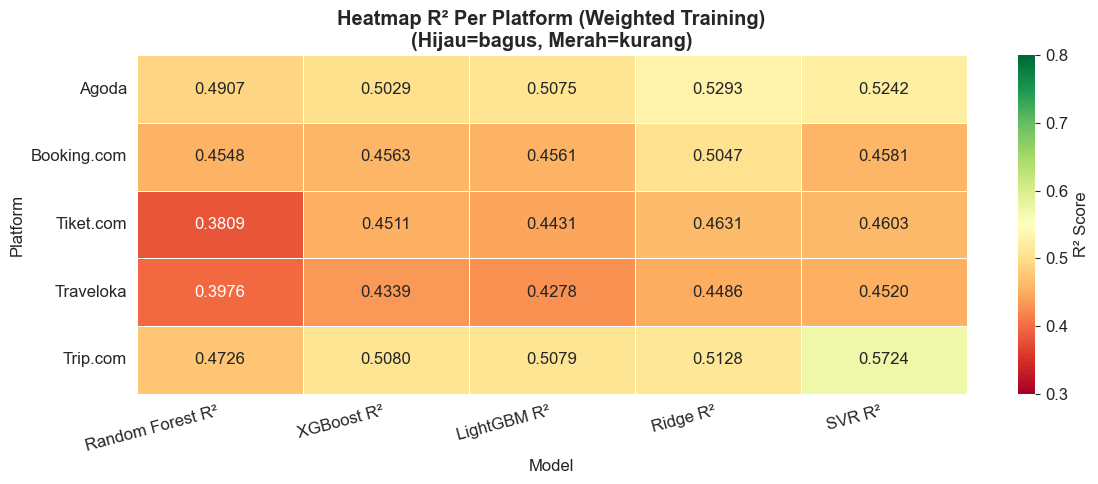


✅ Plot tersimpan: plots/05b_heatmap_per_platform.png


In [9]:
heatmap_data = per_plat_df.set_index('Platform')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.3, vmax=0.8, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'R² Score'})
ax.set_title('Heatmap R² Per Platform (Weighted Training)\n(Hijau=bagus, Merah=kurang)',
             fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Platform')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plots/05b_heatmap_per_platform.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot tersimpan: plots/05b_heatmap_per_platform.png")

## Feature Importance Analysis


FEATURE IMPORTANCE XGBOOST WEIGHTED


,No,Fitur,Importance Score,Keterangan
0,1,facility,0.1876,Fitur dengan kontribusi terbesar dalam model
1,2,cleanliness,0.1574,Fitur rating hotel
2,3,platform_Agoda,0.1521,Fitur asal platform OTA
3,4,service,0.1226,Fitur rating hotel
4,5,location,0.0900,Fitur rating hotel
5,6,platform_Tiket.com,0.0583,Fitur asal platform OTA
6,7,platform_Traveloka,0.0497,Fitur asal platform OTA
7,8,platform_Trip.com,0.0461,Fitur asal platform OTA
8,9,is_facility_available,0.0409,Fitur indikator ketersediaan data
9,10,platform_Booking.com,0.0369,Fitur asal platform OTA


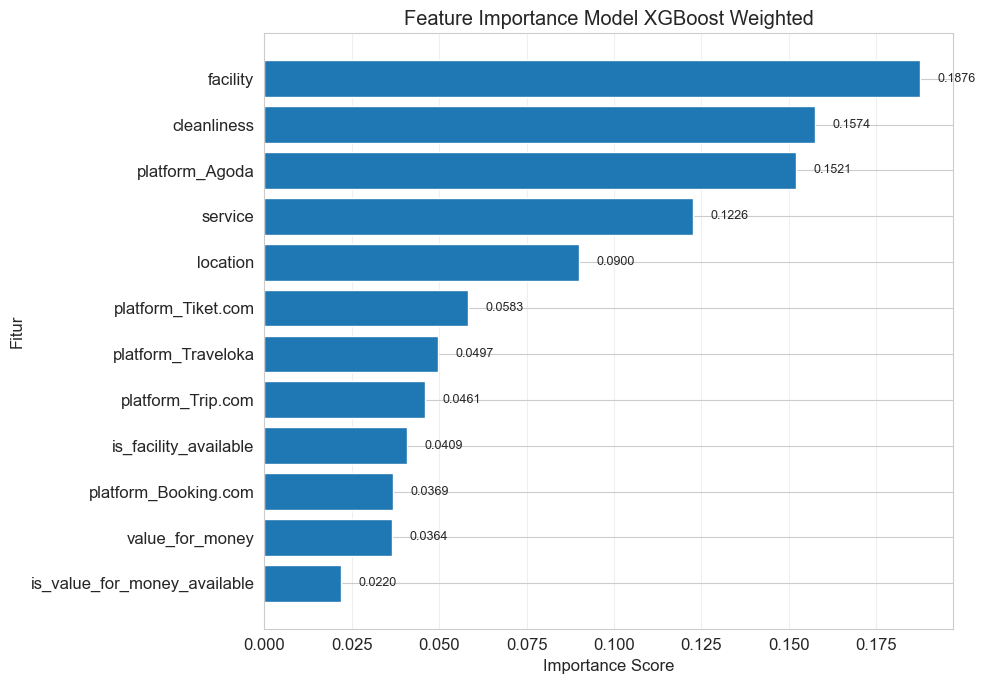

File berhasil disimpan:
- data/bab4_xgboost_feature_importance.csv
- plots/bab4_xgboost_feature_importance.png


In [10]:
# Feature Importance XGBoost Weighted

selected_model_name = 'XGBoost'
selected_model = weighted_models[selected_model_name]

# Ambil nama fitur
feature_names = X_train.columns

# Ambil feature importance dari model XGBoost
importance_values = selected_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance Score': importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    'Importance Score',
    ascending=False
).reset_index(drop=True)

feature_importance_df.insert(0, 'No', range(1, len(feature_importance_df) + 1))

# Tambahkan keterangan otomatis
def importance_description(row):
    feature = row['Fitur']
    rank = row['No']

    if rank == 1:
        return 'Fitur dengan kontribusi terbesar dalam model'
    elif feature in ['cleanliness', 'location', 'service', 'facility', 'value_for_money']:
        return 'Fitur rating hotel'
    elif feature.startswith('platform_'):
        return 'Fitur asal platform OTA'
    elif feature.startswith('is_'):
        return 'Fitur indikator ketersediaan data'
    else:
        return 'Fitur input model'

feature_importance_df['Keterangan'] = feature_importance_df.apply(
    importance_description,
    axis=1
)

feature_importance_report = feature_importance_df.copy()
feature_importance_report['Importance Score'] = feature_importance_report['Importance Score'].round(4)

print("=" * 90)
print("FEATURE IMPORTANCE XGBOOST WEIGHTED")
print("=" * 90)

display(feature_importance_report)

feature_importance_report.to_csv(
    'data/bab4_xgboost_feature_importance.csv',
    index=False
)

# ============================================================
# Plot Feature Importance
# ============================================================

plot_df = feature_importance_report.sort_values(
    'Importance Score',
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    plot_df['Fitur'],
    plot_df['Importance Score']
)

plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.title('Feature Importance Model XGBoost Weighted')
plt.grid(axis='x', alpha=0.3)

for i, value in enumerate(plot_df['Importance Score']):
    plt.text(
        value + 0.005,
        i,
        f'{value:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    'plots/bab4_xgboost_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("File berhasil disimpan:")
print("- data/bab4_xgboost_feature_importance.csv")
print("- plots/bab4_xgboost_feature_importance.png")

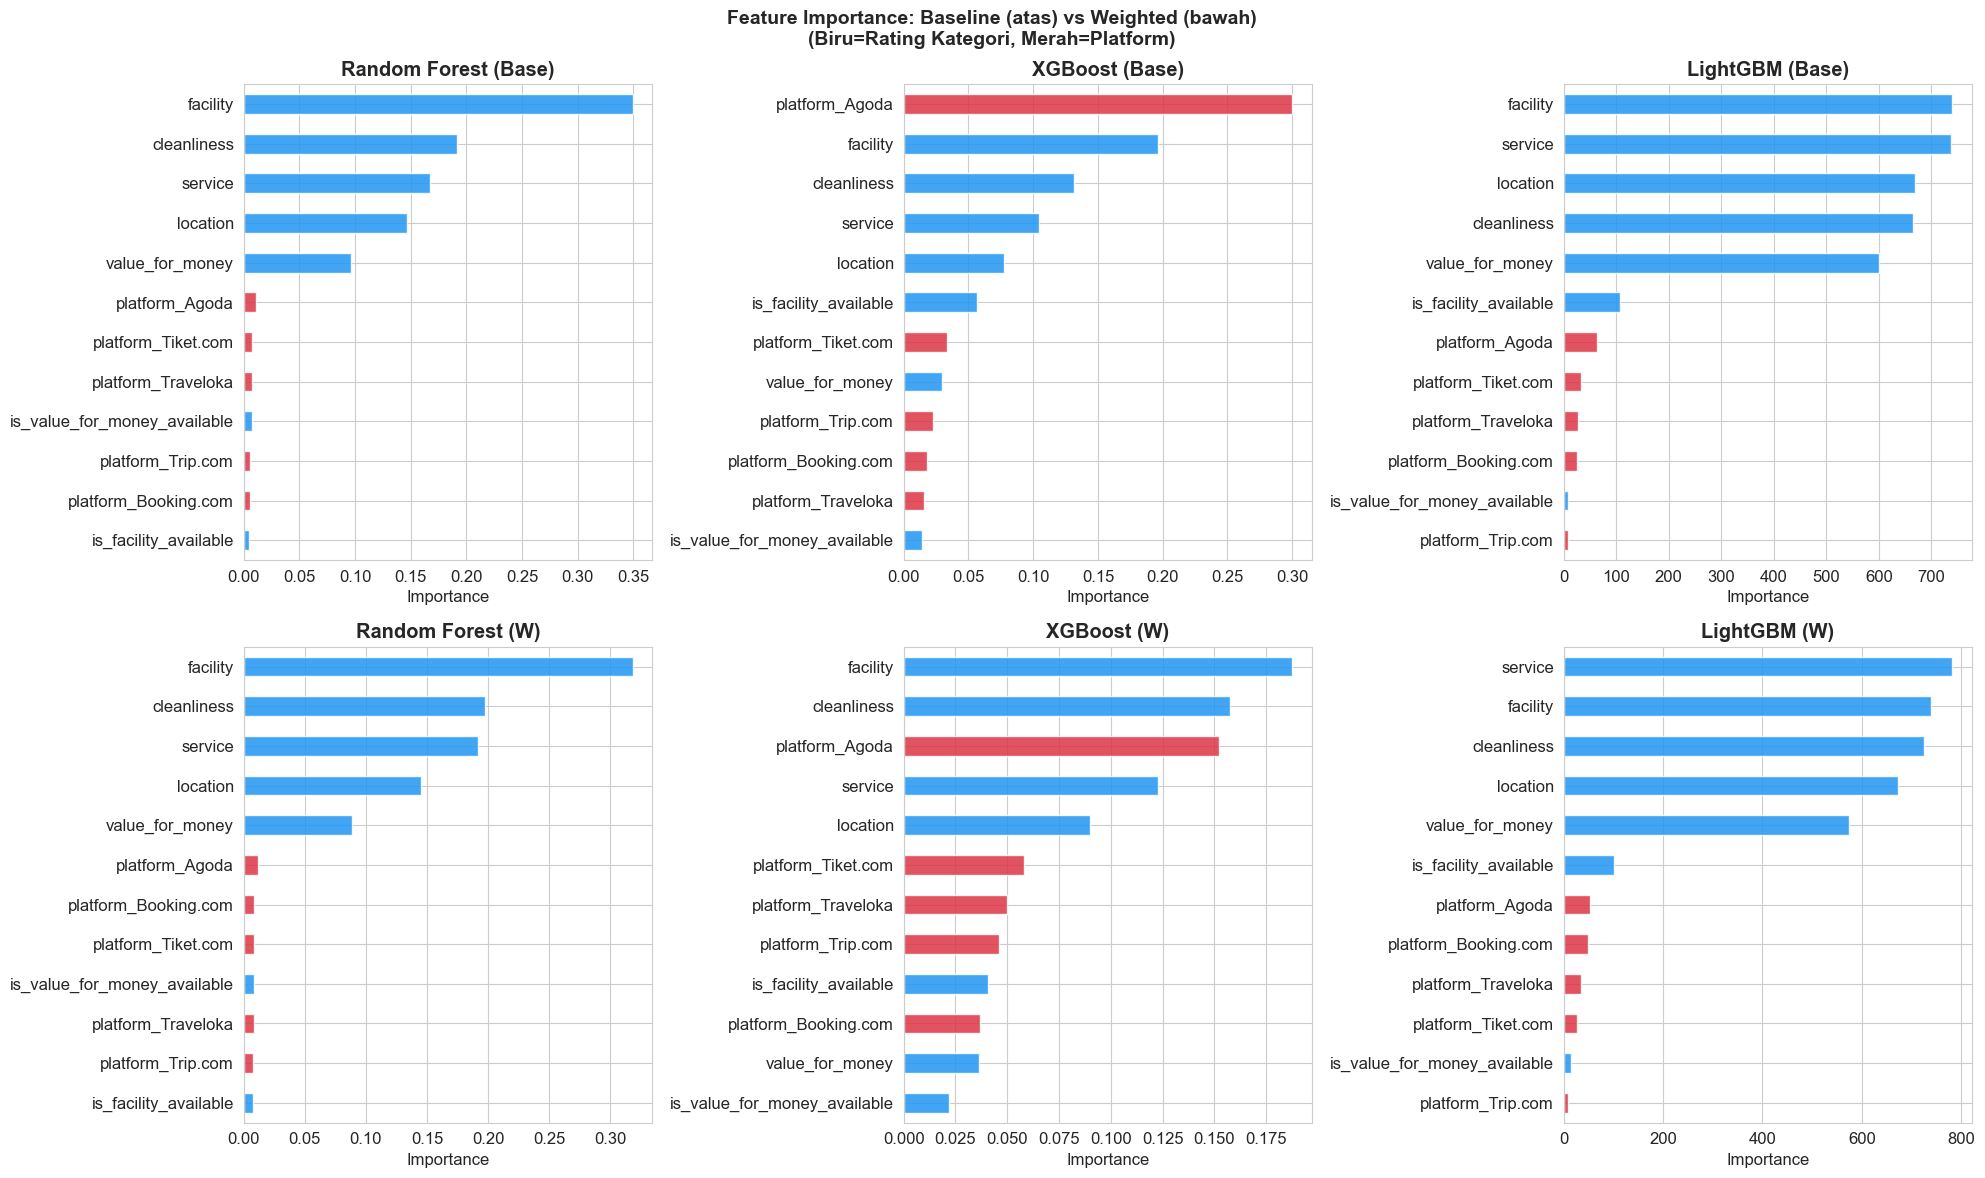

In [11]:
tree_models_base = {
    'Random Forest (Base)' : rf_base,
    'XGBoost (Base)'       : xgb_base,
    'LightGBM (Base)'      : lgbm_base
}

tree_models_w = {
    'Random Forest (W)' : rf_w,
    'XGBoost (W)'       : xgb_w,
    'LightGBM (W)'      : lgbm_w
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i, (name, model) in enumerate(tree_models_base.items()):
    fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    colors = ['#dc3545' if 'platform' in idx else '#2196F3' for idx in fi.index]
    fi.plot(kind='barh', ax=axes[0, i], color=colors, alpha=0.85)
    axes[0, i].set_title(f'{name}', fontweight='bold')
    axes[0, i].set_xlabel('Importance')

for i, (name, model) in enumerate(tree_models_w.items()):
    fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    colors = ['#dc3545' if 'platform' in idx else '#2196F3' for idx in fi.index]
    fi.plot(kind='barh', ax=axes[1, i], color=colors, alpha=0.85)
    axes[1, i].set_title(f'{name}', fontweight='bold')
    axes[1, i].set_xlabel('Importance')

plt.suptitle('Feature Importance: Baseline (atas) vs Weighted (bawah)\n'
             '(Biru=Rating Kategori, Merah=Platform)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
ranking = pd.DataFrame({
    'XGB_Base'      : xgb_base.feature_importances_,
    'XGB_W'         : xgb_w.feature_importances_,
    'LightGBM_Base' : lgbm_base.feature_importances_,
    'LightGBM_W'    : lgbm_w.feature_importances_,
    'RF_Base'       : rf_base.feature_importances_,
    'RF_W'          : rf_w.feature_importances_,
}, index=feature_cols).round(4)

ranking = ranking.sort_values('XGB_W', ascending=False)
print("="*80)
print("📊 RANKING FEATURE IMPORTANCE (sorted by XGBoost Weighted)")
print("="*80)
print(ranking.to_string())

print("\n🔍 Perubahan Dominan Feature XGBoost:")
print(f"   Baseline : platform_Agoda ({xgb_base.feature_importances_[feature_cols.index('platform_Agoda')]:.4f})")
print(f"   Weighted : facility       ({xgb_w.feature_importances_[feature_cols.index('facility')]:.4f})")
print(f"   → Bias platform berhasil dikurangi ✅")

📊 RANKING FEATURE IMPORTANCE (sorted by XGBoost Weighted)
                              XGB_Base   XGB_W  LightGBM_Base  LightGBM_W  RF_Base    RF_W
facility                        0.1964  0.1876            740         739   0.3492  0.3182
cleanliness                     0.1316  0.1574            665         724   0.1914  0.1974
platform_Agoda                  0.3001  0.1521             64          54   0.0112  0.0115
service                         0.1045  0.1226            737         782   0.1671  0.1915
location                        0.0776  0.0900            669         672   0.1466  0.1447
platform_Tiket.com              0.0331  0.0583             34          26   0.0076  0.0082
platform_Traveloka              0.0158  0.0497             28          34   0.0071  0.0080
platform_Trip.com               0.0227  0.0461              8           9   0.0056  0.0080
is_facility_available           0.0566  0.0409            108         101   0.0050  0.0073
platform_Booking.com            

## Justifikasi Pemilihan Model


In [13]:
tradeoff = pd.DataFrame({
    'Model'              : ['SVR', 'Ridge', 'XGBoost', 'LightGBM', 'Random Forest'],
    'R² Test'            : [0.6581, 0.6534, 0.6421, 0.6389, 0.6163],
    'Bias Platform'      : ['✅ Low', '✅ Low', '✅ Low', '✅ Low', '⚠️ Medium'],
    'Overfit Risk'       : ['✅ No', '✅ No', '✅ No', '✅ No', '❌ Yes'],
    'Saveable SHAP'      : ['❌ No', '✅ Yes', '✅ Yes', '✅ Yes', '✅ Yes'],
    'Native FI'          : ['❌ No', '⚠️ Seragam', '✅ Yes', '✅ Yes', '✅ Yes'],
    'Prediction Speed'   : ['⚠️ Slow', '✅ Fast', '✅ Fast', '✅ Fast', '✅ Fast'],
    'Website Ready'      : ['❌ No', '⚠️ Partial', '✅ Yes', '✅ Yes', '⚠️ Overfit']
})
tradeoff = tradeoff.sort_values('R² Test', ascending=False).reset_index(drop=True)
tradeoff.index += 1

print("="*90)
print("⚖️  TRADE-OFF MATRIX — PEMILIHAN MODEL")
print("="*90)
print(tradeoff.to_string())
tradeoff.to_csv('data/05b_tradeoff_matrix.csv', index=False)

⚖️  TRADE-OFF MATRIX — PEMILIHAN MODEL
           Model  R² Test Bias Platform Overfit Risk Saveable SHAP   Native FI Prediction Speed Website Ready
1            SVR   0.6581         ✅ Low         ✅ No          ❌ No        ❌ No          ⚠️ Slow          ❌ No
2          Ridge   0.6534         ✅ Low         ✅ No         ✅ Yes  ⚠️ Seragam           ✅ Fast    ⚠️ Partial
3        XGBoost   0.6421         ✅ Low         ✅ No         ✅ Yes       ✅ Yes           ✅ Fast         ✅ Yes
4       LightGBM   0.6389         ✅ Low         ✅ No         ✅ Yes       ✅ Yes           ✅ Fast         ✅ Yes
5  Random Forest   0.6163     ⚠️ Medium        ❌ Yes         ✅ Yes       ✅ Yes           ✅ Fast    ⚠️ Overfit


## SHAP XGBoost Weighted (Model Terpilih)

In [14]:
print("⏳ Menghitung SHAP values XGBoost Weighted...")
explainer_xgb_w = shap.TreeExplainer(xgb_w)
shap_values_xgb_w = explainer_xgb_w.shap_values(X_test)
print("✅ SHAP values selesai!")
print(f"   Shape: {shap_values_xgb_w.shape}")

⏳ Menghitung SHAP values XGBoost Weighted...
✅ SHAP values selesai!
   Shape: (987, 12)


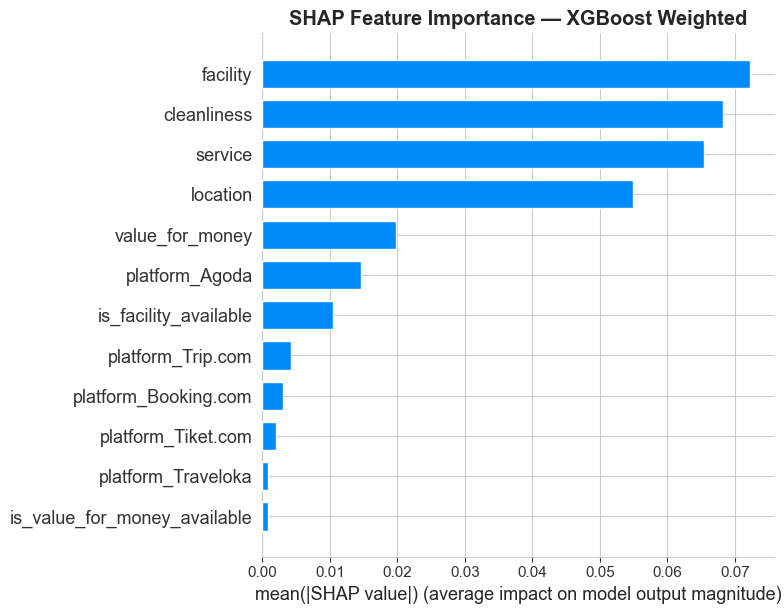

In [15]:
plt.figure()
shap.summary_plot(shap_values_xgb_w, X_test, feature_names=feature_cols,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost Weighted', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_shap_xgb_bar.png', dpi=150, bbox_inches='tight')
plt.show()

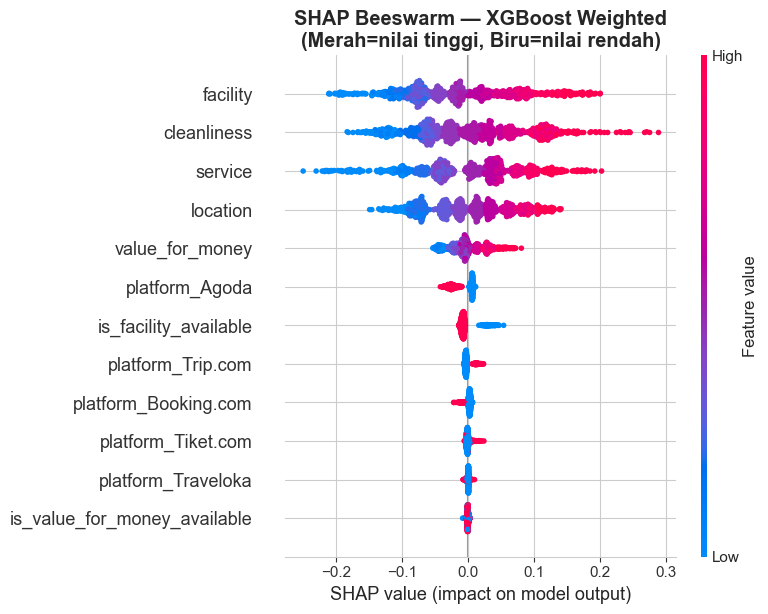

In [16]:
plt.figure()
shap.summary_plot(shap_values_xgb_w, X_test, feature_names=feature_cols,
                  show=False)
plt.title('SHAP Beeswarm — XGBoost Weighted\n(Merah=nilai tinggi, Biru=nilai rendah)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_shap_xgb_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

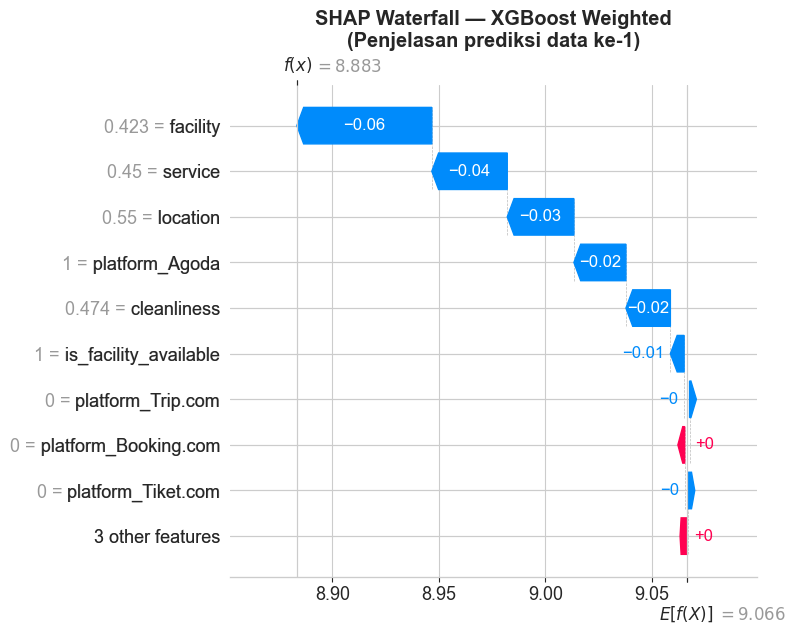


Actual Score    : 8.7000
Predicted Score : 8.8833


In [17]:
sample_idx = 0

shap_exp = shap.Explanation(
    values        = shap_values_xgb_w[sample_idx],
    base_values   = float(explainer_xgb_w.expected_value),
    data          = X_test.iloc[sample_idx].values if hasattr(X_test, 'iloc') else X_test[sample_idx],
    feature_names = feature_cols
)

plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — XGBoost Weighted\n(Penjelasan prediksi data ke-{sample_idx+1})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_shap_xgb_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nActual Score    : {y_test.iloc[sample_idx] if hasattr(y_test, 'iloc') else y_test[sample_idx]:.4f}")
print(f"Predicted Score : {xgb_w.predict(X_test[sample_idx:sample_idx+1])[0]:.4f}")

## Residual Analysis XGBoost Weighted


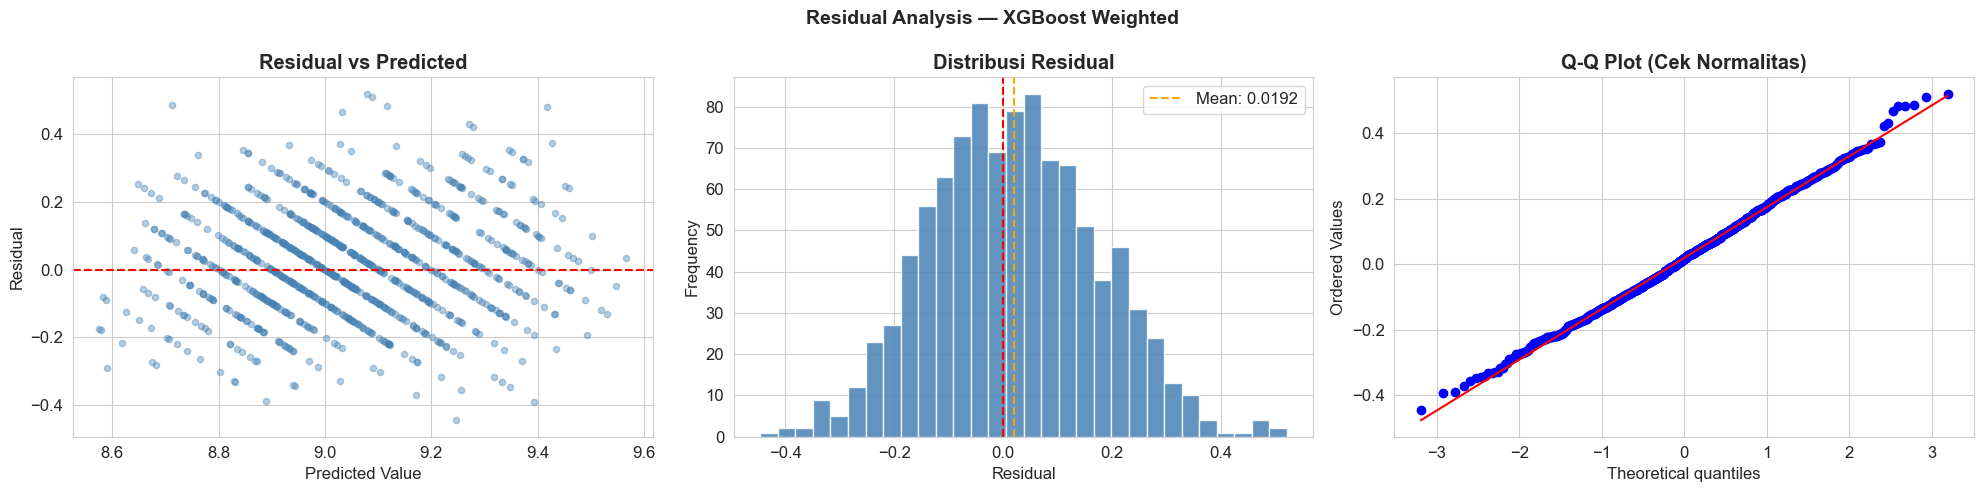


📊 Statistik Residual:
   Mean    : 0.0192
   Std     : 0.1550
   Min     : -0.4460
   Max     : 0.5207
   Skewness: 0.1355
   Kurtosis: -0.1072


In [18]:
y_pred_w = xgb_w.predict(X_test)
residuals = y_test - y_pred_w

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(y_pred_w, residuals, alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual vs Predicted', fontweight='bold')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean: {residuals.mean():.4f}')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].legend()

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Cek Normalitas)', fontweight='bold')

plt.suptitle('Residual Analysis — XGBoost Weighted',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistik Residual:")
print(f"   Mean    : {residuals.mean():.4f}")
print(f"   Std     : {residuals.std():.4f}")
print(f"   Min     : {residuals.min():.4f}")
print(f"   Max     : {residuals.max():.4f}")
print(f"   Skewness: {residuals.skew():.4f}")
print(f"   Kurtosis: {residuals.kurt():.4f}")

##  Error Analysis

🔍 TOP 10 KASUS DENGAN ERROR TERBESAR
    Actual  Predicted  Residual  Abs Error   Platform
1      9.6     9.0793    0.5207     0.5207  Tiket.com
2      9.6     9.0891    0.5109     0.5109  Traveloka
3      9.2     8.7130    0.4870     0.4870   Trip.com
4      9.6     9.1160    0.4840     0.4840  Tiket.com
5      9.9     9.4174    0.4826     0.4826  Tiket.com
6      9.5     9.0329    0.4671     0.4671  Traveloka
7      8.8     9.2460   -0.4460     0.4460   Trip.com
8      9.7     9.2703    0.4297     0.4297  Traveloka
9      9.7     9.2789    0.4211     0.4211  Tiket.com
10     9.0     9.3930   -0.3930     0.3930  Traveloka


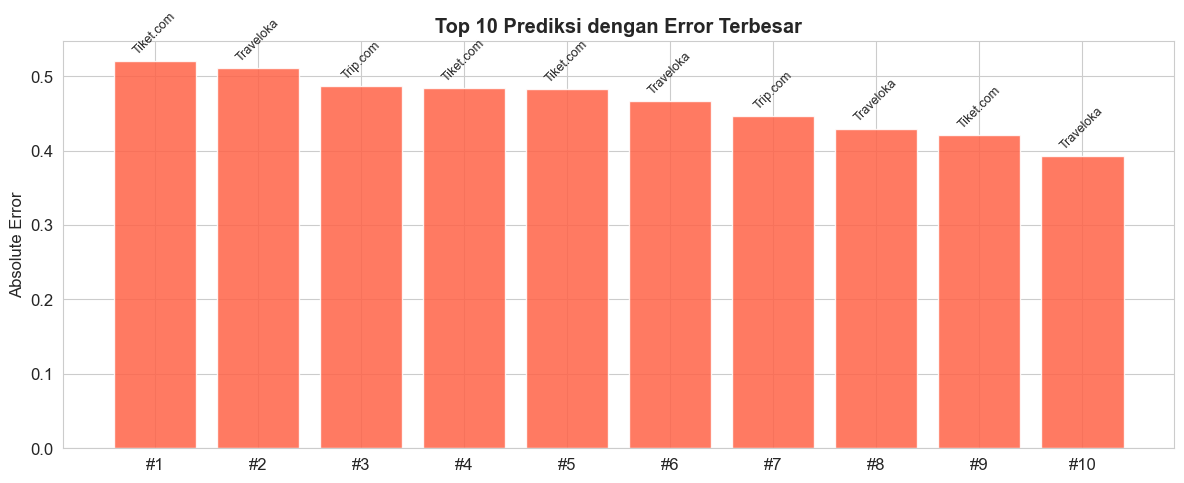


💡 Platform dengan error terbanyak di Top 10:
   Tiket.com: 4 kasus
   Traveloka: 4 kasus
   Trip.com: 2 kasus


In [19]:
error_df = pd.DataFrame({
    'Actual'   : y_test.values if hasattr(y_test, 'values') else y_test,
    'Predicted': y_pred_w,
    'Residual' : residuals.values if hasattr(residuals, 'values') else residuals,
    'Abs Error': np.abs(residuals.values if hasattr(residuals, 'values') else residuals),
    'Platform' : test_platforms.values
})
error_df = error_df.sort_values('Abs Error', ascending=False).head(10).reset_index(drop=True)
error_df.index += 1

print("="*70)
print("🔍 TOP 10 KASUS DENGAN ERROR TERBESAR")
print("="*70)
print(error_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(error_df)), error_df['Abs Error'],
              color='tomato', alpha=0.85, edgecolor='white')
for i, (err, plat) in enumerate(zip(error_df['Abs Error'], error_df['Platform'])):
    ax.text(i, err + 0.01, plat, ha='center', fontsize=9, rotation=45)
ax.set_xticks(range(len(error_df)))
ax.set_xticklabels([f'#{i+1}' for i in range(len(error_df))])
ax.set_ylabel('Absolute Error')
ax.set_title('Top 10 Prediksi dengan Error Terbesar', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05b_top_errors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Platform dengan error terbanyak di Top 10:")
for platform, count in error_df['Platform'].value_counts().items():
    print(f"   {platform}: {count} kasus")

## Kesimpulan Final

In [20]:
print("="*70)
print("📋 KESIMPULAN FINAL — NOTEBOOK 05b")
print("="*70)

print("\n🏆 MODEL TERPILIH: XGBoost Weighted")
print("-"*55)
print(f"   R² Test      : {r2_score(y_test, y_pred_w):.4f}")
print(f"   RMSE Test    : {np.sqrt(mean_squared_error(y_test, y_pred_w)):.4f}")
print(f"   MAE Test     : {mean_absolute_error(y_test, y_pred_w):.4f}")

print("\n✅ PERBANDINGAN LENGKAP 5 MODEL")
print("-"*55)
print("   SVR Weighted      : R² 0.6581 (tertinggi, tapi SHAP tidak bisa disimpan)")
print("   Ridge Weighted    : R² 0.6534 (koefisien seragam, tidak interpretable)")
print("   XGBoost Weighted  : R² 0.6421 ← DIPILIH untuk website")
print("   LightGBM Weighted : R² 0.6389")
print("   RF Weighted       : R² 0.6163 (overfit)")

print("\n🔬 ALASAN PEMILIHAN XGBoost Weighted:")
print("-"*55)
print("   1. Selisih R² hanya 0.016 dari terbaik (tidak signifikan)")
print("   2. Bias platform berhasil diatasi (weighted training)")
print("   3. SHAP TreeExplainer dapat disimpan untuk website")
print("   4. Feature importance native & interpretable")
print("   5. Prediksi instan tanpa loading realtime")
print("   6. Tidak overfit")

print("\n⚠️ KETERBATASAN MODEL:")
print("-"*55)
print("   - R² 0.64 → 36% variasi tidak dapat dijelaskan")
print("   - Dataset sintetis berbasis summary stakeholder")
print("   - Fitur terbatas pada rating numerik per kategori")


📋 KESIMPULAN FINAL — NOTEBOOK 05b

🏆 MODEL TERPILIH: XGBoost Weighted
-------------------------------------------------------
   R² Test      : 0.6109
   RMSE Test    : 0.1561
   MAE Test     : 0.1256

✅ PERBANDINGAN LENGKAP 5 MODEL
-------------------------------------------------------
   SVR Weighted      : R² 0.6581 (tertinggi, tapi SHAP tidak bisa disimpan)
   Ridge Weighted    : R² 0.6534 (koefisien seragam, tidak interpretable)
   XGBoost Weighted  : R² 0.6421 ← DIPILIH untuk website
   LightGBM Weighted : R² 0.6389
   RF Weighted       : R² 0.6163 (overfit)

🔬 ALASAN PEMILIHAN XGBoost Weighted:
-------------------------------------------------------
   1. Selisih R² hanya 0.016 dari terbaik (tidak signifikan)
   2. Bias platform berhasil diatasi (weighted training)
   3. SHAP TreeExplainer dapat disimpan untuk website
   4. Feature importance native & interpretable
   5. Prediksi instan tanpa loading realtime
   6. Tidak overfit

⚠️ KETERBATASAN MODEL:
-------------------------